# Notebook A — Zero-shot environment classification (CLIP, no training)

**Task:** multi-label classification of the **environment** of a frame into the 5 classes
`forest, open_field, water, city` (a frame may have several, e.g. water + forest).

**Approach:** **zero-shot CLIP** — for each class we score a *positive* vs *negative* text prompt
and keep the class if `P(present) >= THRESHOLD`. No training, no segmentation.

Outputs per-frame multi-label predictions to `dataset/eval/env_pred_zeroshot.csv` and the mean
**runtime/frame** to `dataset/eval/runtime_zeroshot.json` for the comparison in `seg_evaluation.ipynb`.


## 1. Setup

In [1]:
import sys, json, time
from pathlib import Path

import numpy as np
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path.cwd()))
import segmentation_common as sc

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
ENV_CLASSES = sc.CATEGORIES["environment"]   # ['forest','open_field','water','city']
print("Device:", DEVICE, "| environment classes:", ENV_CLASSES)

Device: mps | environment classes: ['forest', 'open_field', 'water', 'industry', 'city']


## 2. Configuration

One *positive* and *negative* prompt per environment class drives an independent (multi-label)
decision. `THRESHOLD` is the probability above which a class is considered present.

In [2]:
ENV_PROMPTS = {
    "forest":     ("a forest with many trees",                        "no trees, not a forest"),
    "open_field": ("open farmland or an agricultural field",          "no open fields"),
    "water":      ("a lake, river, sea or large body of water",       "no water is visible"),
    "city":       ("a dense urban city street with many buildings",   "not an urban city scene"),
}
THRESHOLD = 0.5

TEST_IMAGES = Path("../dataset/eval/images")            # labeled test frames live here
PRED_CSV = Path("../dataset/eval/env_pred_zeroshot.csv")
RUNTIME_JSON = Path("../dataset/eval/runtime_zeroshot.json")

## 3. CLIP model

In [3]:
from transformers import CLIPModel, CLIPProcessor

CLIP_NAME = "openai/clip-vit-base-patch32"
clip = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_NAME)


def _clip_text(prompts):
    # getattr(..., "pooler_output", ...) keeps transformers >=5 and <=4 compatible.
    with torch.no_grad():
        t = clip_proc(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
        out = clip.get_text_features(**t)
        feat = getattr(out, "pooler_output", out)
        return feat / feat.norm(dim=-1, keepdim=True)


def _clip_image(pil):
    with torch.no_grad():
        i = clip_proc(images=pil, return_tensors="pt").to(DEVICE)
        out = clip.get_image_features(**i)
        feat = getattr(out, "pooler_output", out)
        return feat / feat.norm(dim=-1, keepdim=True)


# Pre-compute text features for all positive/negative prompts once (speed).
_ENV_TEXT = {c: _clip_text([pos, neg]) for c, (pos, neg) in ENV_PROMPTS.items()}
print("Cached text features for", len(_ENV_TEXT), "classes")

/Users/hendrickfischer/Documents/Education/CAS_Master/Vorlesungen/Semester_2/Bildverarbeitung/RRCP_Project/computer_vision_bikeability_score/CRSvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 60069.56it/s]


Cached text features for 5 classes


## 4. Zero-shot classifier

In [4]:
def classify_environment_zeroshot(image_rgb: np.ndarray, threshold: float = THRESHOLD) -> dict:
    """Multi-label environment prediction -> {class: 0/1} (one independent decision each)."""
    ifeat = _clip_image(Image.fromarray(image_rgb))         # (1, D)
    pred = {}
    for c in ENV_CLASSES:
        sims = (ifeat @ _ENV_TEXT[c].T).squeeze(0)          # (2,) -> [positive, negative]
        p_present = torch.softmax(sims * 100.0, dim=0)[0].item()
        pred[c] = int(p_present >= threshold)
    return pred

## 5. Single-frame test

DJI_0351_frame_00002.jpg -> {'forest': 0, 'open_field': 0, 'water': 0, 'industry': 0, 'city': 0}


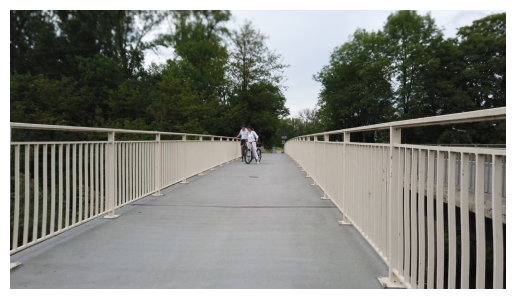

In [7]:
def _first_test_image():
    imgs = sorted(TEST_IMAGES.glob("*.jpg")) + sorted(TEST_IMAGES.glob("*.png"))
    return imgs[0] if imgs else None


sample = _first_test_image()
if sample is None:
    print("No test images under", TEST_IMAGES, "- add frames to label first.")
else:
    img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    print(sample.name, "->", classify_environment_zeroshot(img))
    plt.imshow(img); plt.axis("off"); plt.show()

## 6. Predict over the test set + runtime

Writes one row per image (`image` + a 0/1 column per class) and the mean runtime/frame.

In [8]:
def run_zeroshot_testset() -> pd.DataFrame:
    imgs = sorted(TEST_IMAGES.glob("*.jpg")) + sorted(TEST_IMAGES.glob("*.png"))
    if not imgs:
        print("No test images found - nothing to do.")
        return pd.DataFrame()

    rows, t0 = [], time.perf_counter()
    for fp in imgs:
        img = cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB)
        rows.append({"image": fp.name, **classify_environment_zeroshot(img)})
    ms = (time.perf_counter() - t0) / len(imgs) * 1000

    df = pd.DataFrame(rows)
    PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(PRED_CSV, index=False)
    json.dump({"method": "zeroshot", "ms_per_frame": ms, "n": len(imgs)}, open(RUNTIME_JSON, "w"))
    print(f"Saved {len(df)} predictions -> {PRED_CSV}  |  {ms:.1f} ms/frame")
    return df


predictions = run_zeroshot_testset()
predictions.head()

Saved 14 predictions -> ../dataset/eval/env_pred_zeroshot.csv  |  26.5 ms/frame


,image,forest,open_field,water,industry,city
0,DJI_0351_frame_00002.jpg,0,0,0,0,0
1,DJI_0351_frame_00003.jpg,0,1,0,0,0
2,DJI_0351_frame_00006.jpg,0,1,0,0,0
3,DJI_0351_frame_00008.jpg,0,0,0,0,0
4,DJI_0351_frame_00010.jpg,0,0,0,0,0
